## LOS 3 KPIS PRINCIPALES DEL PROYECTO

1. Completion Rate

2. Client Backtracking Rate

3. Average Time Between Steps


In [7]:
#Pathlib sirve para que todos podamos trabajar desde cualquier sistema operativo.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve().parent
DATA_PATH = ROOT / "data_raw"

print("Directorio actual:", ROOT)
print("Ruta de datos:", DATA_PATH)

Directorio actual: C:\Users\naila\OneDrive\Documentos\Nueva carpeta (2)\Projecto-2-Vanguard-ab-test
Ruta de datos: C:\Users\naila\OneDrive\Documentos\Nueva carpeta (2)\Projecto-2-Vanguard-ab-test\data_raw


El warning DtypeWarning: mixed types no es un error — el archivo cargó bien. Solo significa que algunas columnas tienen tipos mezclados (texto y números).
Para eliminarlo puedes agregar low_memory=False:

In [8]:
df = pd.read_csv("/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv", low_memory=False)
print(df.shape)
print(df.dtypes)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/gabrielbohorquez/Desktop/Ironhack/Semana_5/PROYECTO_2/Projecto-2-Vanguard-ab-test/data_raw/vanguard_cleaned_todos unidos_(Gabriel).csv'

In [ ]:
# Verificar
df.head()

,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0


In [ ]:
# ENTENDER EL FUNNEL
df["process_step"].value_counts()

process_step
start      108910
step_1      73432
step_2      61768
step_3      53628
confirm     45403
Name: count, dtype: int64

Ver:
✔ qué pasos existen
✔ cuál es el más frecuente
✔ si confirm aparece menos

## KPI 1: COMPLETION RATE
Completion Rate mide: qué porcentaje de usuarios llega a confirm.

In [ ]:
# Usuarios totales - Cuenta usuarios únicos porque un usuario puede tener varias filas. Si contamos filas, estaríamos contando varias veces a un mismo usuario.
total_users = df["client_id"].nunique()

total_users

58391

In [ ]:
# Usuarios que completaron el proceso - De nuevo, contamos usuarios únicos para evitar contar varias veces a un mismo usuario.
completed_users = df[df["process_step"] == "confirm"]["client_id"].nunique()

completed_users

37190

45403 - puede haber usuarios repetidos.
37190 - usuarios que completaron el proceso.

In [ ]:
# Completion Rate
completion_rate = completed_users / total_users

completion_rate

0.636913222928191

63% de los usuarios completaron el proceso. ¿63% es bueno o malo?: depende de la comparación Test vs Control.
Interfas clara, proceso simple, menos fricción, experiencia eficiente

In [ ]:
# Mostrar el resultado en porcentaje
print(f"Completion Rate: {completion_rate:.2%}")

Completion Rate: 63.69%


## COMPLETION RATE TEST VS CONTROL

In [ ]:
# Crear dataset por usuario. 1 fila por usuario. Con: True = completó, False = no completó
completed_df = (
    df.groupby("client_id")["process_step"]
    .apply(lambda x: "confirm" in x.values)
    .reset_index()
)

completed_df.columns = ["client_id", "completed"]

In [ ]:
# Agregar variation al dataset por usuario. Esto Agrega: Test vs Control
variation_df = df[["client_id", "Variation"]].drop_duplicates()

completed_df = completed_df.merge(
    variation_df,
    on="client_id",
    how="left"
)

In [ ]:
print(completed_df.columns.tolist())

['client_id', 'completed', 'Variation']


Tiene Variation_x y Variation_y por un merge duplicado. Fix:

In [ ]:
# Completion por grupo. Calcula: completion promedio por grupo
completion_by_group = (
    completed_df.groupby("Variation")["completed"]
    .mean()
)

completion_by_group

Variation
Control    0.630919
Test       0.682778
Name: completed, dtype: float64

## El grupo Test parece completar más el proceso.
PERO: todavía NO sabemos si es estadísticamente significativo.

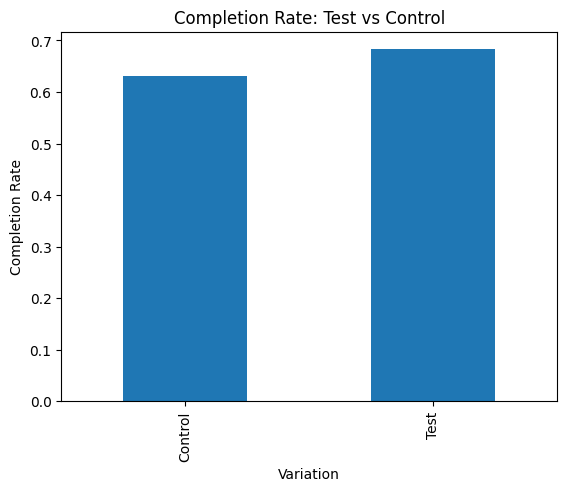

In [ ]:
# Gráfico de barras para comparar completion rate entre grupos
completion_by_group.plot(kind="bar")

plt.title("Completion Rate: Test vs Control")

plt.ylabel("Completion Rate")

plt.show()

## Ver 
* qué grupo es mayor
* si la diferencia parece relevante

El gráfico muestra:

Control: 63% completion rate
Test: 68% completion rate

El grupo Test supera al Control en 5 puntos porcentuales, lo que sugiere que el nuevo diseño mejora la tasa de completación. 
La diferencia parece relevante pero hay que validarla estadísticamente con un test de hipótesis (chi-square o z-test de proporciones) para confirmar que no es por azar.

## KPI 2: Client Backtracking Rate

Este KPI mide la proporción de clientes que realizan al menos un retroceso dentro del flujo digital.

A diferencia de una métrica por evento o transición, esta definición evita contar varias veces al mismo cliente y permite comparar de forma más justa el comportamiento entre Control y Test.

Definición oficial provisional:

- Numerador: clientes únicos con al menos un retroceso.
- Denominador: clientes únicos del grupo analizado.
- Comparación: Control vs Test.


In [ ]:
# KPI 2: Client Backtracking Rate
# Definimos el orden lógico del funnel para detectar retrocesos reales.

step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df_back = df.copy()

df_back["step_num"] = df_back["process_step"].map(step_order)
df_back = df_back.sort_values(["client_id", "visit_id", "date_time"])

df_back["previous_step"] = df_back.groupby(["client_id", "visit_id"])["step_num"].shift(1)

df_back["is_backtrack"] = (
    df_back["previous_step"].notna()
    & df_back["step_num"].notna()
    & (df_back["step_num"] < df_back["previous_step"])
)

client_backtracking = (
    df_back.groupby("client_id", as_index=False)["is_backtrack"]
    .max()
)

client_backtracking = client_backtracking.merge(
    df[["client_id", "Variation"]].drop_duplicates(),
    on="client_id",
    how="left",
    validate="one_to_one"
)

backtracking_summary = (
    client_backtracking
    .groupby("Variation")
    .agg(
        backtracking_clients=("is_backtrack", "sum"),
        total_clients=("client_id", "nunique")
    )
)

backtracking_summary["backtracking_rate"] = (
    backtracking_summary["backtracking_clients"] / backtracking_summary["total_clients"]
)

backtracking_summary


### Interpretación del Client Backtracking Rate

El grupo Test presenta una proporción mayor de clientes con al menos un retroceso dentro del flujo.

Esto indica que, aunque el rediseño mejora la finalización del proceso, también puede estar generando más fricción o dudas en determinados pasos del recorrido digital.

Por lo tanto, este KPI debe interpretarse junto con Completion Rate: el rediseño convierte mejor, pero no necesariamente reduce toda la fricción del usuario.


In [ ]:
# Validación estadística del Client Backtracking Rate
# Prueba Z manual de diferencia de proporciones para evitar dependencias externas.

from math import sqrt, erf

control_success = backtracking_summary.loc["Control", "backtracking_clients"]
control_n = backtracking_summary.loc["Control", "total_clients"]

test_success = backtracking_summary.loc["Test", "backtracking_clients"]
test_n = backtracking_summary.loc["Test", "total_clients"]

control_rate = control_success / control_n
test_rate = test_success / test_n

absolute_diff = test_rate - control_rate
relative_lift = absolute_diff / control_rate

pooled_rate = (control_success + test_success) / (control_n + test_n)
standard_error = sqrt(
    pooled_rate * (1 - pooled_rate) * ((1 / control_n) + (1 / test_n))
)

z_stat = absolute_diff / standard_error

# CDF normal estándar usando erf
p_value_one_sided = 1 - (0.5 * (1 + erf(z_stat / sqrt(2))))
p_value_two_sided = 2 * min(p_value_one_sided, 1 - p_value_one_sided)

print("=== CLIENT BACKTRACKING RATE ===")
print(f"Control: {control_rate:.2%}")
print(f"Test: {test_rate:.2%}")
print(f"Diferencia absoluta Test - Control: {absolute_diff:.2%}")
print(f"Incremento relativo: {relative_lift:.2%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value unilateral: {p_value_one_sided:.10f}")
print(f"P-value bilateral: {p_value_two_sided:.10f}")

if p_value_one_sided < 0.05:
    print("Decisión: el Client Backtracking Rate es significativamente mayor en Test.")
else:
    print("Decisión: no hay evidencia suficiente de mayor backtracking en Test.")


### Diagnóstico por transición

Para entender dónde se concentra la fricción, analizamos qué transiciones generan más retrocesos.

Este análisis permite separar dos situaciones distintas:

- El usuario retrocede al inicio del flujo.
- El usuario retrocede desde pasos avanzados después de haber progresado.

Esta lectura es más accionable que una tasa agregada, porque orienta mejoras concretas de UX.


In [ ]:
# Diagnóstico de retrocesos por transición

df_back["previous_process_step"] = (
    df_back.groupby(["client_id", "visit_id"])["process_step"].shift(1)
)

df_back["transition"] = (
    df_back["previous_process_step"].astype(str)
    + " -> "
    + df_back["process_step"].astype(str)
)

backtracking_transitions = (
    df_back[df_back["is_backtrack"]]
    .groupby(["Variation", "transition"])
    .size()
    .rename("backtracks")
    .reset_index()
)

group_total_backtracks = (
    backtracking_transitions
    .groupby("Variation")["backtracks"]
    .sum()
    .rename("group_total_backtracks")
    .reset_index()
)

backtracking_transitions = backtracking_transitions.merge(
    group_total_backtracks,
    on="Variation",
    how="left"
)

backtracking_transitions["share_within_group"] = (
    backtracking_transitions["backtracks"] / backtracking_transitions["group_total_backtracks"]
)

top_backtracking_transitions = (
    backtracking_transitions
    .sort_values(["Variation", "backtracks"], ascending=[True, False])
)

top_backtracking_transitions.head(20)


### Conclusión del KPI 2

El rediseño de la interfaz aumenta la tasa de finalización, pero también incrementa el porcentaje de clientes que retroceden al menos una vez dentro del flujo.

Esto no invalida el rediseño, pero sí indica que la mejora debe implementarse con cautela: la nueva experiencia parece más efectiva para convertir, aunque todavía presenta puntos de fricción que deben optimizarse antes de una implementación definitiva a gran escala.


## KPI 3: Average Time Between Steps

Este KPI mide el tiempo medio entre pasos del flujo digital.

La métrica ayuda a detectar si un grupo avanza de forma más rápida o más lenta dentro del proceso. Debe interpretarse con cuidado, ya que tiempos más largos pueden reflejar fricción, dudas, pausas naturales o mayor atención del usuario.


In [ ]:
# KPI 3: Average Time Between Steps

df_time = df.copy()
df_time["date_time"] = pd.to_datetime(df_time["date_time"], errors="coerce")

df_time = df_time.sort_values(["client_id", "visit_id", "date_time"])

df_time["previous_time"] = (
    df_time.groupby(["client_id", "visit_id"])["date_time"].shift(1)
)

df_time["time_between_steps_seconds"] = (
    df_time["date_time"] - df_time["previous_time"]
).dt.total_seconds()

# Filtramos tiempos inválidos o extremos evidentes para evitar distorsiones.
df_time_valid = df_time[
    (df_time["time_between_steps_seconds"].notna())
    & (df_time["time_between_steps_seconds"] >= 0)
]

time_by_group = (
    df_time_valid
    .groupby("Variation")["time_between_steps_seconds"]
    .mean()
    .rename("avg_time_between_steps_seconds")
)

time_by_group


### Conclusión del KPI 3

El tiempo medio entre pasos complementa la lectura de Completion Rate y Client Backtracking Rate.

Si el grupo Test finaliza más, pero también tarda más o retrocede más, la conclusión correcta no es que el rediseño sea perfecto, sino que es prometedor y necesita optimización adicional.

La decisión de negocio debe considerar los tres KPIs en conjunto.


In [ ]:
# Usuarios por paso - Cuenta usuarios únicos por paso para entender el funnel
funnel = (
    df.groupby("process_step")["client_id"]
    .nunique()
    .sort_values(ascending=False)
)

funnel

process_step
start      57851
step_1     49341
step_2     45385
step_3     42313
confirm    37190
Name: client_id, dtype: int64

In [ ]:
# Calcular porcentaje de usuarios que pasan por cada paso
funnel_sorted = funnel.sort_values(ascending=False)
dropoff = funnel_sorted.pct_change(periods=-1) * 100
print(dropoff.round(2))

process_step
start      17.25
step_1      8.72
step_2      7.26
step_3     13.78
confirm      NaN
Name: client_id, dtype: float64


Conclusión: el mayor abandono está en start (17.25%) y step_3 → confirm (13.78%).

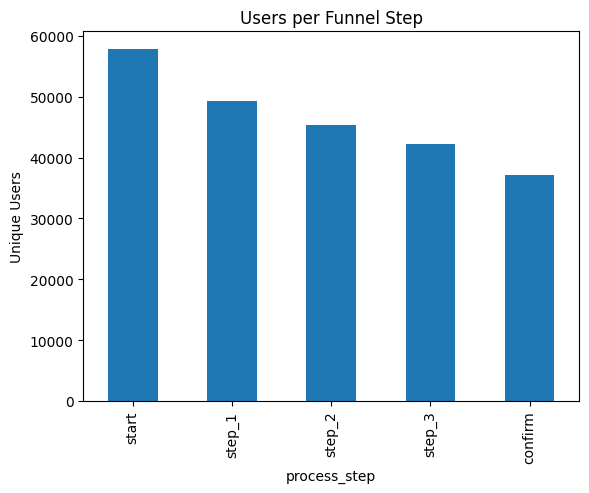

In [ ]:
# Funnel gráfico
funnel.plot(kind="bar")

plt.title("Users per Funnel Step")

plt.ylabel("Unique Users")

plt.show()

## SEGMENTACIÓN POR EDAD

In [ ]:
# Crear grupos edad
df["age_group"] = pd.cut(
    df["clnt_age"],
    bins=[0,30,50,70,100],
    labels=["18-30","31-50","51-70","70+"]
)

In [ ]:
# Completion por edad - ¿qué segmentos tienen más éxito?
completion_age = (
    df[df["process_step"] == "confirm"]
    .groupby("age_group")["client_id"]
    .nunique()
)

completion_age

/var/folders/t3/nrw97mdn40j3lpprlyf3l8ym0000gn/T/ipykernel_32611/1001987289.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df["process_step"] == "confirm"]


age_group
18-30     7378
31-50    13477
51-70    14320
70+       1790
Name: client_id, dtype: int64

51-70 es el segmento con más completions — tiene sentido para Vanguard ya que son clientes con más patrimonio e inversiones activas.

In [ ]:
# Para verlo en proporción (% del total por grupo):
total_age = df.groupby("age_group", observed=True)["client_id"].nunique()
completion_rate_age = (completion_age / total_age * 100).round(2)
print(completion_rate_age)

age_group
18-30    67.89
31-50    68.25
51-70    64.95
70+      53.71
Name: client_id, dtype: float64


18-30: 67.89%
31-50: 68.25% 
51-70: 64.95%
70+ :  53.71%

Conclusión — en proporción el segmento más exitoso es 31-50. Los mayores de 70 tienen la tasa más baja (53.71%), tal vez por dificultad con el proceso digital.